# 02 Model
Sample construction, the school-grouped split, nested feature tiers, the model bake-offs, and the
Part 2 (student-facing) model. Results figures live in `03_results.ipynb`; robustness checks in
`04_robustness.ipynb` — both rerun this pipeline as their setup.

Reads `Data/output/teacher_principal_named_columns.csv` (from `01_build_dataset.ipynb` or downloaded
per `Data/README.md`) and the codebook in `Data/`.

The P1-vs-P2 dual importance chart lives in `03_results.ipynb` (it needs Part 1 importance).

In [1]:
# ============================================================
# CELL 0 — paths (portable: finds the repo by walking up from cwd)
# No editing needed on any machine. If it errors, open the repo
# folder itself in VS Code / Jupyter and restart the kernel.
# ============================================================
from pathlib import Path

def find_root(start=None, depth=6):
    p = start or Path.cwd()
    for _ in range(depth):
        if (p / "Data").exists() and (p / "Model").exists():
            return p
        p = p.parent
    raise FileNotFoundError(
        f"repo root not found walking up from {Path.cwd()} — "
        "in VS Code use File > Open Folder on summer26-teacher-ai-readiness, "
        "reopen this notebook, restart the kernel")

ROOT = find_root()
DATA_DIR = ROOT / "Data"                 # codebook + small CSVs
SPSS_DIR = DATA_DIR / "SPSS"             # raw TALIS .sav files (gitignored)
OUT_DIR  = DATA_DIR / "output"           # everything the notebooks produce (gitignored)
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("repo root:", ROOT)

repo root: c:\Users\elif_\Documents\summer26-teacher-ai-readiness


## Building the AI-module analysis sample

Q36 ("Have you used AI in your teaching?") is a **rotated** survey item, so a non-answer can mean two very different things:

- **Code 8 — "not administered":** a random ~2/3 of teachers never saw the question by design. This is *not missing data* — they were never asked — so we filter these rows out explicitly.
- **Code 9 — "omitted":** teachers who *were* asked but declined to answer.
  This is genuine outcome-missingness. We mark it `NaN` (rather than dropping
  it here) so it flows through the same complete-case filter as every other
  missing value in the assembly step.

Keeping the omitted rows at this stage keeps "not administered" and "declined"
conceptually distinct, and lets us count the omitters before they're dropped.

In [2]:
# ============================================================
# CELL 1 — load merged file, build ai_sample
# ============================================================
import re
import numpy as np
import pandas as pd

merged = pd.read_csv(DATA_DIR / "output" / "teacher_principal_named_columns.csv",
                     encoding="utf-8-sig", low_memory=False)
assert any(c.startswith("P_TC") for c in merged.columns), "no principal columns - wrong file?"

q36_col = next(c for c in merged.columns if c.startswith("TT4G36"))
q36_num = pd.to_numeric(merged[q36_col], errors="coerce")
ai_sample = merged[q36_num != 8].copy()
ai_sample[q36_col] = pd.to_numeric(ai_sample[q36_col], errors="coerce").replace(9, np.nan)
print("administered the AI module:", len(ai_sample))

administered the AI module: 92894


## Selecting teacher features (RQ1)

From the exploratory correlation screen (see `q36_correlations.xlsx`) plus technology-adoption theory, we select **18 teacher-level features**, one per construct, to predict AI adoption.

**We deliberately drop some candidates to avoid redundancy** — including a variable that duplicates another only inflates the model and splits its
importance across correlated columns:

- **Self-efficacy** — the subscales (T4SECLS/SEINS/SEENG) *and* overall
  **T4SELF** → we keep only **TT4G27M** (digital self-efficacy), the AI-relevant
  facet. General teaching confidence isn't specific to technology, so it's a
  weaker fit for predicting AI adoption.
- **T4JOYTCH** → dropped; near-duplicate of **T4JOBSAT** (r ≈ 0.6).
- **T4WELS** (umbrella wellbeing) → dropped in favour of the specific stress
  scales (**T4WLOADT**, **T4STBEH**).
- **T4EXINF**, **TT4G10** → dropped; overlap with **T4COLES** and **T4TNSCH**.
- **The TT4G16 hours battery** → collapsed to a single hours variable (**TT4G15**);
  the rest were near-zero in the screen.
- **TT4G50A–C** → dropped entirely (no overlap with the Q36 rotation form).

We build two derived features:
- **`prep_general`** — the mean of the six general-preparation items (TT4G07A–E, G),
  so "digital preparedness" (TT4G07F) stays a distinct predictor rather than
  being diluted by the whole battery.
- **AI-belief composites** — the ten belief items (TT4G35A–J, scored 1–4;
  code 5 = "I don't know" recoded to missing) are averaged into
  **`ai_benefit_mean`** (items A–E) and **`ai_risk_mean`** (items F–J), giving
  two interpretable scores instead of ten correlated columns.

We also constructed teacher–principal **disagreement measures** (perception gaps in participation, leadership, satisfaction), but these showed no predictive
signal in preliminary analysis and were dropped.

---

**Reasoning behind the feature selection.** The features chosen map onto established technology-adoption frameworks (TAM, Davis 1989; UTAUT,
Venkatesh et al. 2003): perceived usefulness (`ai_benefit_mean`), ease of use (`TT4G27M`, `TT4G07F`), social influence (`T4COLES`, `T4VALP`), facilitating
conditions (`TT4G21G`, AI training), and demographic moderators (`T4TAGEGR`).TALIS items serve as proxies for these constructs rather than validated scales.

In [4]:
# ============================================================
# CELL 2 — teacher features (RQ1) + prep_general + belief composites
# Definitions = official TALIS 2024 codebook labels (abbreviated)
# ============================================================
cb = pd.read_csv(DATA_DIR / "talis2024_teacher_codebook.csv")

def tcol(v):
    """short code -> actual teacher column name in merged/ai_sample"""
    return next(c for c in ai_sample.columns if c.startswith(v + " ") or c == v)

# --- AI-belief COMPOSITES (mean of items; code 5 "I don't know" -> missing) ---
# Q35 scale: 1=Strongly disagree ... 4=Strongly agree, 5=I don't know (NOT on scale)
def belief_mean(items):
    B = ai_sample[[tcol(v) for v in items]].apply(pd.to_numeric, errors='coerce')
    B = B.replace(5, 2.5)                       # ← THIS LINE: "don't know" (5) -> neutral 2.5
    B = B.where(B.isin([1, 2, 2.5, 3, 4]))      # ← note 2.5 added to valid values
    return B.mean(axis=1).where(B.notna().sum(axis=1) >= 1)
ai_sample['ai_benefit_mean'] = belief_mean([f'TT4G35{c}' for c in 'ABCDE'])  # benefits
ai_sample['ai_risk_mean']    = belief_mean([f'TT4G35{c}' for c in 'FGHIJ'])  # risks/concerns

# --- general pedagogical preparation composite ---
# Q7a-e,g: prepared for content / subject pedagogy / general pedagogy /
# classroom practice / multicultural settings / student development
prep_codes = ['TT4G07A', 'TT4G07B', 'TT4G07C', 'TT4G07D', 'TT4G07E', 'TT4G07G']
P = ai_sample[[tcol(v) for v in prep_codes]].apply(pd.to_numeric, errors='coerce')
P = P.where(~P.isin([6, 8, 9]))
ai_sample['prep_general'] = P.mean(axis=1).where(P.notna().sum(axis=1) >= 4)

feature_cols = (
    # --- AI / digital core ---
    ['TT4G21G',   # Q21g: professional learning included "using AI for teaching and learning" (yes/no)
     'TT4G07F',   # Q7f: felt prepared for "use of digital resources and tools" (initial education)
     'TT4G27M']   # Q27m: self-efficacy — support learning through digital resources and tools

    # --- AI beliefs: two COMPOSITE scores (replaces the 10 Q35 items) ---
    + ['ai_benefit_mean',  # mean of Q35A-E; higher = agrees AI is beneficial
       'ai_risk_mean']     # mean of Q35F-J; higher = agrees AI is risky/concerning

    # --- derived: general pedagogical preparation ---
    + ['prep_general']

    # --- professional environment (TALIS derived scales) ---
    + ['T4COLES',   # Professional collaboration in lessons among teachers
       'T4TLEAD',   # Teacher leadership
       'T4VALP']    # Perceptions of value and policy influence
                    # NOTE: T4SELF (overall self-efficacy) dropped — overlaps with
                    # TT4G27M (digital self-efficacy), the AI-relevant facet we keep

    # --- wellbeing / stress (derived scales) ---
    + ['T4JOBSAT',  # Job satisfaction, overall
       'T4WLOADT',  # Workload stress
       'T4STBEH',   # Student behaviour stress
       'T4CHFAT']   # Change fatigue

    # --- workload ---
    + ['TT4G15']    # Q15: hours teaching at this school, most recent full week

    # --- demographics / employment (grouped) ---
    + ['T4TAGEGR',  # Teacher age (grouped)
       'T4TEMPWH',  # Employment status by working hours (grouped; CATEGORICAL)
       'T4TNSCH']   # Number of schools the teacher works at

    # --- structure ---
    + ['CNTRY']     # Country alpha code (CATEGORICAL, fixed effect)
)

withlabels = {
    'TT4G21G':         'Received AI Training',
    'ai_benefit_mean': 'AI-benefit beliefs',
    'ai_risk_mean':    'AI-risk beliefs',
    'CNTRY':           'Country',
    'TT4G27M':         'Digital self-efficacy',
    'TT4G07F':         'Digital preparedness',
    'prep_general':    'General preparation',
    'T4TAGEGR':        'Age group',
    'T4COLES':         'Professional collaboration',
    'T4TLEAD':         'Teacher leadership',
    'T4VALP':          'Perceived value & influence',
    'T4JOBSAT':        'Job satisfaction',
    'T4WLOADT':        'Workload stress',
    'T4STBEH':         'Student-behaviour stress',
    'T4CHFAT':         'Change fatigue',
    'TT4G15':          'Teaching hours',
    'T4TEMPWH':        'Employment status',
    'T4TNSCH':         'Number of schools',
}

assert len(feature_cols) == len(set(feature_cols))
print("teacher features:", len(feature_cols))   # 18

teacher features: 18


In [5]:
# ---- sanity check (fast, safe to skip): recode loop handles every feature ----
DERIVED = ['prep_general', 'ai_benefit_mean', 'ai_risk_mean']
categoricals = ['CNTRY', 'T4SCHLOC', 'T4TEMPWH']

for v in feature_cols:
    if v in categoricals:
        status = 'categorical'
    elif v in DERIVED:
        status = 'derived (skip recode)'
    elif v in cb['variable_name'].values:
        status = 'raw + in codebook'
    else:
        status = 'WARNING: raw but NOT in codebook'
    print(f"{v:18s} {status}")

TT4G21G            raw + in codebook
TT4G07F            raw + in codebook
TT4G27M            raw + in codebook
ai_benefit_mean    derived (skip recode)
ai_risk_mean       derived (skip recode)
prep_general       derived (skip recode)
T4COLES            raw + in codebook
T4TLEAD            raw + in codebook
T4VALP             raw + in codebook
T4JOBSAT           raw + in codebook
T4WLOADT           raw + in codebook
T4STBEH            raw + in codebook
T4CHFAT            raw + in codebook
TT4G15             raw + in codebook
T4TAGEGR           raw + in codebook
T4TEMPWH           categorical
T4TNSCH            raw + in codebook
CNTRY              categorical


## Building the modeling sample

Here we assemble the final analysis table: the teacher features (recoding survey
missing-codes to `NaN`), attach the target `y` (1 = used AI, 0 = did not), and
keep only **complete cases** — teachers with valid values on every feature.

**Why complete-case?** The model needs all features present for each teacher, so
any row with a missing value is dropped. We report the accounting explicitly —
how many rows we start with, how many survive, and *where* the losses come from —
because complete-case selection isn't random: teachers who skip items may differ
systematically, and a reader should see the trade-off.

We also check that no country is disproportionately dropped (which would quietly
narrow what our cross-national claims cover) and that no country cell becomes too
small to model reliably. A useful check is whether the complete-case **AI-use
rate** matches the full-sample rate: if the two diverge, complete-casing is
biasing the sample toward one kind of teacher.

**Why school variables are handled separately.** Several countries (e.g. Japan,
Poland, Iceland, the Netherlands) do not report the full set of principal
(school) variables, so requiring them would drop those systems entirely and
skew the sample toward higher-data countries. We therefore keep the main model
to **teacher-level features** — retaining broad country coverage — and run the
school-context comparison separately, on the subset of teachers with complete
principal data (see the school-context section). In the current sample, Teacher's age group is missing from Singapoure respondents but we kept at the cost of it since it came as a strong predictor. 

In [6]:
# ============================================================
# CELL 4 — assembly: ONE fixed complete-case sample + accounting
# ============================================================
def col_for(v):
    if v in ai_sample.columns:          # prep_general, composites
        return v
    return tcol(v)

all_short = feature_cols #+ school_block           # teacher features only (school block is for subset analysis)
D = ai_sample[[col_for(v) for v in all_short]].copy()
D.columns = all_short

# per-variable missing codes from the codebook (raw teacher vars only)
cb_codes = {}
for _, row in cb[cb.variable_name.isin(feature_cols)].iterrows():
    cb_codes[row.variable_name] = [float(x) for x in
        re.findall(r"(\d+)\s*=", str(row.special_missing_or_skip_codes))]

categoricals = ['CNTRY', 'T4SCHLOC', 'T4TEMPWH']
DERIVED = ['prep_general', 'ai_benefit_mean', 'ai_risk_mean']   # ← already clean, skip
for v in feature_cols:
    if v in categoricals or v in DERIVED:                        # ← was: == 'prep_general'
        continue
    D[v] = pd.to_numeric(D[v], errors='coerce')
    if cb_codes.get(v):
        D[v] = D[v].where(~D[v].isin(cb_codes[v]))

D['TT4G21G'] = D['TT4G21G'].map({1: 1, 2: 0})     # yes/no -> 1/0

D['y'] = (pd.to_numeric(ai_sample[q36_col], errors='coerce') == 1).astype(float)
D.loc[ai_sample[q36_col].isna(), 'y'] = np.nan
D['IDSCHOOL'] = ai_sample[next(c for c in ai_sample.columns if c.startswith('IDSCHOOL'))]
D['CNTRY'] = D['CNTRY'].astype(str).str.strip()
D['T4TEMPWH'] = pd.to_numeric(D['T4TEMPWH'], errors='coerce').where(
    lambda s: ~s.isin([8, 9]))

# ---- missingness accounting ----
n0 = len(D)
print("worst 10 columns by missingness (%):")
print(D[all_short].isna().mean().mul(100).round(1).sort_values(ascending=False).head(10).to_string())

data = D.dropna()
print(f"\ncomplete cases: {len(data):,} of {n0:,}  ({len(data)/n0*100:.1f}%)")
print(f"AI-use rate: full {D['y'].mean():.3f}  |  complete-case {data['y'].mean():.3f}")

kept = pd.Series(D.index.isin(data.index), index=D.index)
drop_by_cntry = (1 - kept.groupby(D['CNTRY']).mean()).mul(100).round(1)
print("\ncountries losing the most rows (%):")
print(drop_by_cntry.sort_values(ascending=False).head(8).to_string())

for v in ['T4TAGEGR', 'TT4G21G']:
    print(f"{v}: kept mean {D.loc[kept, v].mean():.3f} | dropped mean {D.loc[~kept, v].mean():.3f}")

cc = data['CNTRY'].value_counts()
print("\nsmallest country cells:", cc.tail(3).to_dict())
print("countries with <200 rows:", (cc < 200).sum())

worst 10 columns by missingness (%):
TT4G21G         7.0
T4VALP          3.7
T4JOBSAT        3.6
T4CHFAT         3.5
T4STBEH         3.5
T4WLOADT        3.4
TT4G07F         3.1
T4TLEAD         2.9
prep_general    2.8
TT4G15          2.6

complete cases: 75,817 of 92,894  (81.6%)
AI-use rate: full 0.409  |  complete-case 0.414

countries losing the most rows (%):
CNTRY
NLD    100.0
SGP    100.0
HRV     56.0
SAU     31.0
SWE     30.3
ISR     28.7
XKX     28.0
ZAF     27.0
T4TAGEGR: kept mean 2.877 | dropped mean 2.942
TT4G21G: kept mean 0.414 | dropped mean 0.437

smallest country cells: {'NOR': 380, 'ISL': 343, 'MNE': 340}
countries with <200 rows: 0


## Train/test split and modeling setup

**School-grouped split.** Teachers are nested in schools, and teachers from the same school are more alike than teachers from different schools. A naïve random
split would put some teachers from a school in training and others in test letting the model learn at each school's pattern and inflating our scores. Therefore, we split by **school**: every teacher from a given school lands entirely in training *or* test, never both. An assertion confirms no school appears on both sides. 

**Consistent preprocessing (no leakage).** All preprocessing — scaling numeric features, one-hot encoding categoricals (country, employment status) — lives inside a scikit-learn `Pipeline`, fit only on the training data, so the test set never influences how features are prepared. A school-grouped 70/30 split yielded 53,188 training and 23,574 test observations with near-identical outcome prevalence (41.3% vs. 41.1%), confirming the grouped split preserved class balance despite not being stratified.

In [7]:
# ============================================================
# CELL 6 — school-grouped split + helpers (used by all comparisons)
# ============================================================
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score
from scipy.stats import norm

RANDOM_STATE = 42
CATEGORICALS = ['CNTRY', 'T4TEMPWH']          # T4SCHLOC gone (school block out)

gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_STATE)
tr_idx, te_idx = next(gss.split(data, data['y'], groups=data['IDSCHOOL']))
train, test = data.iloc[tr_idx], data.iloc[te_idx]
assert not (set(train['IDSCHOOL']) & set(test['IDSCHOOL'])), "schools leak!"
print(f"train {len(train):,} | test {len(test):,}")
print(f"AI share — train {train['y'].mean():.3f} | test {test['y'].mean():.3f}")

def make_pipe(feats, clf=None):
    cat = [c for c in feats if c in CATEGORICALS]
    num = [c for c in feats if c not in CATEGORICALS]
    steps = [('num', StandardScaler(), num)]
    if cat:
        steps.append(('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat))
    if clf is None:
        clf = GradientBoostingClassifier(random_state=RANDOM_STATE)
    return Pipeline([('prep', ColumnTransformer(steps)), ('clf', clf)])


HEADLINE_CLF = lambda: GradientBoostingClassifier(random_state=RANDOM_STATE)

def delong(y, p1, p2):
    y = np.asarray(y); pos, neg = y == 1, y == 0
    m, n = pos.sum(), neg.sum()
    def struct(p):
        x, yv = p[pos], p[neg]
        v10 = np.array([(np.sum(xi > yv) + .5*np.sum(xi == yv))/n for xi in x])
        v01 = np.array([(np.sum(x > yi) + .5*np.sum(x == yi))/m for yi in yv])
        return v10, v01, v10.mean()
    a1v,a1w,a1 = struct(np.asarray(p1)); a2v,a2w,a2 = struct(np.asarray(p2))
    s10 = np.cov(np.vstack([a1v,a2v])); s01 = np.cov(np.vstack([a1w,a2w]))
    var = (s10[0,0]+s10[1,1]-2*s10[0,1])/m + (s01[0,0]+s01[1,1]-2*s01[0,1])/n
    z = (a1-a2)/np.sqrt(var) if var > 0 else 0.0
    return a1, a2, 2*norm.sf(abs(z))

train 52,533 | test 23,284
AI share — train 0.414 | test 0.412


## Nested feature comparison

Instead of fitting one model and reading off coefficients, we build the model in
**nested tiers** — adding one conceptual block at a time, on the *same teachers*
and the *same train/test split* — and measure how much each block improves
discrimination (ROC-AUC). The gain (ΔAUC) at each step shows what that block
actually contributes.

- **A — teacher traits:** demographics, self-efficacy, collaboration, wellbeing,
  preparation — characteristics that plausibly *predate* AI adoption. This is our
  "cleanest" tier, least entangled with the outcome.
- **A + T — add AI training:** does professional development in AI predict use?
- **A + T + Bb / Br — add belief composites separately:** benefit beliefs and
  risk beliefs entered one at a time, so we can see which kind of belief carries
  the signal.
- **A + T + B — add both belief composites.**

Two features are deliberately held out of Tier A because they are the most
**entangled with the outcome**: AI training (a teacher inclined toward AI may
seek out AI training) and AI beliefs (using AI shapes what a teacher believes
about it). Measured in the same survey wave, these can't be read causally — so
Tier A gives the honest "how predictable is adoption from things adoption didn't
cause?" baseline, and the later tiers show how much predictive (not causal)
signal training and beliefs add.

## How well can we predict AI adoption — and what drives it?

We measure model quality with **ROC-AUC**: the probability the model ranks a random AI-user above a random non-user. 0.5 = coin flip, 1.0 = perfect.

**Building the model in tiers.** Rather than one black-box model, we add feature groups one at a time and watch how much each improves AUC. The *gain* at eachstep is the finding — a group that doesn't move the number, doesn't matter:

| Tier | What it adds |
|------|--------------|
| **Dummy** | baseline (random guessing) — the floor |
| **A=teacher traits** | who the teacher is (efficacy, collaboration, wellbeing, prep) |
| **A + Training** | did their professional development cover AI? |
| **A + T + Benefit beliefs** | do they think AI is useful? |
| **A + T + Risk beliefs** | do they worry about AI's risks? |
| **A + T + All beliefs** | both belief types together |


In [8]:
# ============================================================
# CELL 5 — nested model tiers
# ============================================================
# Tier A = "pre-adoption" traits: exclude AI training and belief composites
# (the features most entangled with the outcome), keep the rest.
tier_a = [c for c in feature_cols
          if c != 'TT4G21G' and c not in ('ai_benefit_mean', 'ai_risk_mean')]

feature_sets = {
    'A: teacher traits':        tier_a,
    'A+T: +AI training':        tier_a + ['TT4G21G'],
    'A+T+Bb: +benefit beliefs': tier_a + ['TT4G21G', 'ai_benefit_mean'],
    'A+T+Br: +risk beliefs':    tier_a + ['TT4G21G', 'ai_risk_mean'],
    'A+T+B: +all beliefs':      tier_a + ['TT4G21G', 'ai_benefit_mean', 'ai_risk_mean'],
}
for k, v in feature_sets.items():
    print(f"{k:28s} {len(v)} features")

A: teacher traits            15 features
A+T: +AI training            16 features
A+T+Bb: +benefit beliefs     17 features
A+T+Br: +risk beliefs        17 features
A+T+B: +all beliefs          18 features


## Nested comparison: what drives adoption?

We fit each tier on the training set and score it on the held-out test set, building up from the baseline. Each step's AUC gain shows how much that feature
block contributes.

**Two honesty checks run alongside:**
- **DeLong tests** — when a belief block adds only a small AUC bump, DeLong tells us whether that gain is statistically real or just noise. We report both the *size* of the gain and its p-value, because with a large test set even trivial differences can be "significant" — the size is what tells us if it matters.
- **Null-target test** — we shuffle the outcome labels and refit; a clean model should collapse to AUC ≈ 0.5, since there's nothing real to learn. If it scored higher, something would be leaking. (Ours passes.)

The dummy baseline sits at 0.498, confirming chance-level is ~0.50 and everything above it reflects real signal. Teacher traits alone reach 0.709, demographics/background carry meaningful information. Adding AI training lifts it to 0.777, a solid increment. Adding benefit beliefs gives the biggest jump (0.777 → 0.833), while risk beliefs alone add less (0.777 → 0.793). The full model tops out at 0.835.

In [9]:
# ============================================================
# CELL 7 — nested comparison + null-target check
# ============================================================
fitted = {}
dummy = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
dummy.fit(train[tier_a], train['y'])
print(f"{'dummy baseline':<28} "
      f"{roc_auc_score(test['y'], dummy.predict_proba(test[tier_a])[:,1]):.3f}")

for name, feats in feature_sets.items():
    pipe = make_pipe(feats).fit(train[feats], train['y'])
    proba = pipe.predict_proba(test[feats])[:, 1]
    fitted[name] = (pipe, feats, proba)
    print(f"{name:<28} {roc_auc_score(test['y'], proba):.3f}")

# incremental belief tests
_, _, p_b = delong(test['y'].values, fitted['A+T+Bb: +benefit beliefs'][2],
                   fitted['A+T+B: +all beliefs'][2])
_, _, p_r = delong(test['y'].values, fitted['A+T+Br: +risk beliefs'][2],
                   fitted['A+T+B: +all beliefs'][2])
print(f"\nbenefits->all: DeLong p={p_b:.2e}  (does RISK add beyond benefits?)")
print(f"risks->all:    DeLong p={p_r:.2e}  (does BENEFIT add beyond risks?)")

# null-target leakage check
y_shuf = train['y'].sample(frac=1, random_state=0).values
full = feature_sets['A+T+B: +all beliefs']
null_auc = roc_auc_score(test['y'],
    make_pipe(full).fit(train[full], y_shuf).predict_proba(test[full])[:, 1])
print(f"\nnull-target AUC: {null_auc:.3f}  (expect ~0.50)")

dummy baseline               0.498
A: teacher traits            0.711
A+T: +AI training            0.778
A+T+Bb: +benefit beliefs     0.833
A+T+Br: +risk beliefs        0.793
A+T+B: +all beliefs          0.836

benefits->all: DeLong p=2.45e-11  (does RISK add beyond benefits?)
risks->all:    DeLong p=6.95e-109  (does BENEFIT add beyond risks?)

null-target AUC: 0.460  (expect ~0.50)


## Model comparison: which algorithm fits best?

Before committing to one model, we compare families fairly — each evaluated by
**grouped 5-fold cross-validation on the training set only**, so the test set
stays untouched and every fold keeps schools intact (no leakage). All models run
at library defaults: we're comparing *algorithm families*, not tuned
configurations, so the winner reflects the method rather than a hyperparameter
search.

**Result: gradient boosting wins (CV AUC 0.831 ± 0.003)**, with LightGBM (0.830)
and random forest (0.825) close behind. The linear models — logistic, Lasso, and
ElasticNet — cluster at 0.815. The tree ensembles beat the linear models by a
clear but modest margin (~0.016, roughly five standard deviations), which tells
us the data has some non-linear structure and feature interactions a linear model
can't capture — enough to justify a tree model, but the gap is small enough that
an interpretable linear model would still perform respectably.

Our selection rule is "the simplest model within noise of the best." No linear
model comes within a fold's standard deviation of gradient boosting, so we adopt
**gradient boosting** as the headline model.

In [10]:
# ============================================================
# CELL 8 — model bake-off (full roster): grouped CV, training set only
# ============================================================
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

full_feats = feature_sets['A+T+B: +all beliefs']          # full model (no school block)
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

candidates = {
    'LogisticRegression':  LogisticRegression(max_iter=2000),
    'Lasso (L1) Logistic': LogisticRegression(penalty='l1', solver='saga', max_iter=2000),
    'ElasticNet Logistic': LogisticRegression(penalty='elasticnet', solver='saga',
                                              l1_ratio=0.5, max_iter=2000),
    'RandomForest':        RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                                  random_state=RANDOM_STATE),
    'GradientBoosting':    GradientBoostingClassifier(random_state=RANDOM_STATE),
}

try:
    from xgboost import XGBClassifier
    candidates['XGBoost'] = XGBClassifier(n_estimators=200, random_state=RANDOM_STATE,
                                          eval_metric='logloss', n_jobs=-1)
except ImportError:
    print("(xgboost not installed)")

try:
    from lightgbm import LGBMClassifier
    candidates['LightGBM'] = LGBMClassifier(n_estimators=300, random_state=RANDOM_STATE,
                                            verbosity=-1)
except ImportError:
    print("(lightgbm not installed — HistGB is the sklearn equivalent)")

results = {}
for name, clf in candidates.items():
    s = cross_val_score(make_pipe(full_feats, clf), train[full_feats], train['y'],
                        cv=cv, groups=train['IDSCHOOL'], scoring='roc_auc', n_jobs=-1)
    results[name] = (s.mean(), s.std())

# --- sorted comparison table ---
print(f"{'model':<22} {'CV AUC':>7} {'sd':>6}")
print("-" * 40)
for name, (auc, sd) in sorted(results.items(), key=lambda kv: -kv[1][0]):
    print(f"{name:<22} {auc:7.3f} {sd:6.3f}")

    # ---- bake-off chart: model comparison with error bars ----
import matplotlib.pyplot as plt

ranked = sorted(results.items(), key=lambda kv: kv[1][0])   # ascending for barh
names  = [n for n, _ in ranked]
aucs   = [v[0] for _, v in ranked]
sds    = [v[1] for _, v in ranked]



model                   CV AUC     sd
----------------------------------------
GradientBoosting         0.831  0.002
LightGBM                 0.830  0.003
RandomForest             0.825  0.003
Lasso (L1) Logistic      0.815  0.002
ElasticNet Logistic      0.815  0.002
LogisticRegression       0.815  0.002
XGBoost                  0.814  0.004


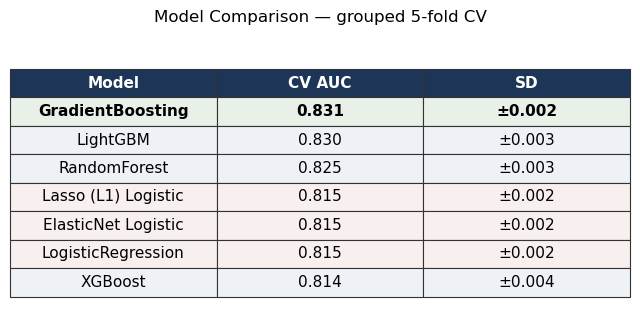

In [11]:
# ---- Comparison table (clean, colors show tree vs linear) ----
tree_models = {'GradientBoosting', 'HistGB', 'RandomForest', 'XGBoost', 'LightGBM'}
ranked = sorted(results.items(), key=lambda kv: -kv[1][0])

rows = [[name, f'{auc:.3f}', f'±{sd:.3f}'] for name, (auc, sd) in ranked]

fig, ax = plt.subplots(figsize=(6.5, 0.5 + 0.42*len(rows))); ax.axis('off')
tbl = ax.table(cellText=rows,
               colLabels=['Model', 'CV AUC', 'SD'],
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1, 1.6)

for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#333'); cell.set_linewidth(0.8)
    if r == 0:
        cell.set_facecolor('#1d3557'); cell.set_text_props(color='white', fontweight='bold')
    elif r == 1:
        cell.set_facecolor('#e8f0e8'); cell.set_text_props(fontweight='bold')
    else:
        model_name = rows[r-1][0]
        cell.set_facecolor('#eef2f7' if model_name in tree_models else '#f7f0ee')

ax.set_title("Model Comparison — grouped 5-fold CV",
             fontsize=12, pad=14)
plt.tight_layout()
plt.savefig(DATA_DIR / "output" / "model_bakeoff_table.png", dpi=150, bbox_inches='tight')
plt.show()

### Why the outcome isn't "student-facing vs teacher-facing"
A natural alternative is two exclusive classes — y=1 student-facing, y=0 teacher-facing. The purposes
aren't exclusive, though: teacher-facing uses (summarising a topic 73%, lesson plans 72%) are
near-universal among AI users, so most student-facing users are *also* teacher-facing users. Exclusive
classes would either discard everyone who does both (most of the sample) or need an arbitrary
"which side dominates" rule.

So the question we can actually ask is: **given the near-universal teacher-facing baseline, does the
teacher's AI use additionally reach students?** y=1 = any of the three student-facing purposes; y=0 = none
of them — which in practice is almost exactly the teacher-facing-only group (the `teacher_only` share
printed below). Earlier alternative definitions we tested and discarded ("leans pedagogical",
"2+ pedagogical items") are archived in `explorations.ipynb`.

In [12]:
# ============================================================
# CELL 14 — Part 2 target: student-facing AI use among users
# ============================================================
from sklearn.inspection import permutation_importance

STUDENT_FACING = ['TT4G37A', 'TT4G37G', 'TT4G37H']   # assess/mark, student data, practice
TEACHER_FACING = ['TT4G37B', 'TT4G37C', 'TT4G37F']   # summarise, lesson plans, comms
AMBIGUOUS      = ['TT4G37D', 'TT4G37E']              # SEN, auto-adjust -> sensitivity only
ALL37 = STUDENT_FACING + TEACHER_FACING + AMBIGUOUS

p2 = ai_sample[pd.to_numeric(ai_sample[q36_col], errors='coerce') == 1].copy()
for c in ALL37:
    p2[c] = pd.to_numeric(p2[tcol(c)], errors='coerce').map({1: 1, 2: 0})
p2 = p2.dropna(subset=STUDENT_FACING + TEACHER_FACING)   # must answer all 6 core items
print(f"AI users with complete purpose data: {len(p2):,}")

p2['y_core']  = p2[STUDENT_FACING].max(axis=1).astype(int)
p2['y_broad'] = p2[STUDENT_FACING + AMBIGUOUS].max(axis=1).fillna(p2['y_core']).astype(int)
print(f"base rate y_core:  {p2['y_core'].mean():.3f}")
print(f"base rate y_broad: {p2['y_broad'].mean():.3f}")
flipped = (p2['y_core'] != p2['y_broad']).mean()
print(f"y_broad flips {flipped*100:.1f}% of labels (sensitivity check)")

# teacher-facing-only (the holdout group): student-facing = 0
teacher_only = ((p2['y_core'] == 0) & (p2[TEACHER_FACING].max(axis=1) == 1)).mean()
print(f"teacher-facing only (no student-facing use): {teacher_only*100:.1f}%")
# ============================================================
# CELL 15 — Part 2 sample + grouped split (teacher features only)
# ============================================================
all_short = feature_cols                               # teacher-only, matches Part 1
D2 = p2[[col_for(v) for v in all_short]].copy()
D2.columns = all_short
for v in feature_cols:
    if v in CATEGORICALS or v in ('prep_general', 'ai_benefit_mean', 'ai_risk_mean'):
        continue
    D2[v] = pd.to_numeric(D2[v], errors='coerce')
    if cb_codes.get(v):
        D2[v] = D2[v].where(~D2[v].isin(cb_codes[v]))
D2['TT4G21G'] = D2['TT4G21G'].map({1: 1, 2: 0})
D2['y'] = p2['y_core'].values
D2['IDSCHOOL'] = p2[next(c for c in p2.columns if c.startswith('IDSCHOOL'))].values
D2['CNTRY'] = D2['CNTRY'].astype(str).str.strip()
D2['T4TEMPWH'] = pd.to_numeric(D2['T4TEMPWH'], errors='coerce')
D2.loc[D2['T4TEMPWH'].isin([8, 9]), 'T4TEMPWH'] = np.nan

data2 = D2.dropna()
print(f"Part 2 complete cases: {len(data2):,} ({len(data2)/len(D2)*100:.1f}%)")
print(f"positive rate: {data2['y'].mean():.3f} | trained share: {data2['TT4G21G'].mean():.3f}")

tri2, tei2 = next(GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_STATE)
                  .split(data2, data2['y'], groups=data2['IDSCHOOL']))
train2, test2 = data2.iloc[tri2], data2.iloc[tei2]
assert not (set(train2['IDSCHOOL']) & set(test2['IDSCHOOL']))
print(f"train {len(train2):,} | test {len(test2):,}")

# ============================================================
# CELL 15b — Part 2 nested comparison + null-target check
# Mirrors CELL 7, with tiers redesigned to isolate CNTRY,
# since Part 2's question is context vs individual readiness.
# Requires: train2/test2 (CELL 15), make_pipe, HEADLINE_CLF,
#           delong, tier_a, feature_sets, DummyClassifier
# ============================================================
from sklearn.metrics import average_precision_score

tier_a_nc = [f for f in tier_a if f != 'CNTRY']      # teacher traits w/o country

feature_sets2 = {
    'C: country only':          ['CNTRY'],
    'A-C: traits (no country)': tier_a_nc,
    'A: traits + country':      tier_a,
    'A+T: +AI training':        tier_a + ['TT4G21G'],
    'A+T+B: +all beliefs':      feature_sets['A+T+B: +all beliefs'],
    'A+T+B-C: full, no country': [f for f in feature_sets['A+T+B: +all beliefs']
                                  if f != 'CNTRY'],
}

fitted2 = {}
dummy2 = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
dummy2.fit(train2[tier_a], train2['y'])
d_proba = dummy2.predict_proba(test2[tier_a])[:, 1]
print(f"{'dummy baseline':<28} AUC {roc_auc_score(test2['y'], d_proba):.3f}")

print(f"{'tier':<28} {'AUC':>6} {'PR-AUC':>7}   (base rate {test2['y'].mean():.3f})")
for name, feats in feature_sets2.items():
    pipe = make_pipe(feats, HEADLINE_CLF()).fit(train2[feats], train2['y'])
    proba = pipe.predict_proba(test2[feats])[:, 1]
    fitted2[name] = (pipe, feats, proba)
    print(f"{name:<28} {roc_auc_score(test2['y'], proba):>6.3f} "
          f"{average_precision_score(test2['y'], proba):>7.3f}")

# --- the two comparisons that carry the Part 2 thesis ---
_, _, p_ctx = delong(test2['y'].values,
                     fitted2['C: country only'][2],
                     fitted2['A+T+B: +all beliefs'][2])
print(f"\ncountry-only vs full: DeLong p={p_ctx:.2e} "
      f"(do individual features add beyond country?)")

_, _, p_ind = delong(test2['y'].values,
                     fitted2['A+T+B-C: full, no country'][2],
                     fitted2['A+T+B: +all beliefs'][2])
print(f"no-country vs full:   DeLong p={p_ind:.2e} "
      f"(does country add beyond all individual features?)")

# --- null-target leakage check (same as Part 1) ---
y_shuf2 = train2['y'].sample(frac=1, random_state=0).values
full2 = feature_sets2['A+T+B: +all beliefs']
null_auc2 = roc_auc_score(
    test2['y'],
    make_pipe(full2, HEADLINE_CLF()).fit(train2[full2], y_shuf2)
        .predict_proba(test2[full2])[:, 1])
print(f"\nnull-target AUC: {null_auc2:.3f}  (expect ~0.50)")

# ============================================================
# CELL 16 — Part 2 model + PR-AUC (dual chart -> 03_results)
# ============================================================
from sklearn.metrics import average_precision_score

feats2 = feature_sets['A+T+B: +all beliefs']           # was +S: +school context
pipe2 = make_pipe(feats2, HEADLINE_CLF()).fit(train2[feats2], train2['y'])
proba2 = pipe2.predict_proba(test2[feats2])[:, 1]
print(f"ROC-AUC: {roc_auc_score(test2['y'], proba2):.3f}")
print(f"PR-AUC:  {average_precision_score(test2['y'], proba2):.3f} "
      f"(base rate {test2['y'].mean():.3f})")

r2 = permutation_importance(pipe2, test2[feats2], test2['y'],
                            scoring='roc_auc', n_repeats=10,
                            random_state=RANDOM_STATE, n_jobs=-1)
imp2 = (pd.DataFrame({'feature': feats2, 'auc_drop': r2.importances_mean})
          .sort_values('auc_drop', ascending=False).reset_index(drop=True))
print(imp2.head(15).to_string(index=False))

# quick Part 2 model check — does GB still win?
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score

cv2 = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for nm, clf in {'GradientBoosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
                'RandomForest': RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE),
                'Logistic': LogisticRegression(max_iter=2000)}.items():
    s = cross_val_score(make_pipe(feats2, clf), train2[feats2], train2['y'],
                        cv=cv2, groups=train2['IDSCHOOL'], scoring='roc_auc', n_jobs=-1)
    print(f"{nm:18s} {s.mean():.3f} ± {s.std():.3f}")

AI users with complete purpose data: 35,708
base rate y_core:  0.698
base rate y_broad: 0.818
y_broad flips 12.0% of labels (sensitivity check)
teacher-facing only (no student-facing use): 26.2%
Part 2 complete cases: 30,689 (85.9%)
positive rate: 0.704 | trained share: 0.654
train 21,901 | test 8,788
dummy baseline               AUC 0.514
tier                            AUC  PR-AUC   (base rate 0.708)
C: country only               0.698   0.832
A-C: traits (no country)      0.682   0.829
A: traits + country           0.727   0.862
A+T: +AI training             0.729   0.863
A+T+B: +all beliefs           0.745   0.871
A+T+B-C: full, no country     0.714   0.847

country-only vs full: DeLong p=4.52e-24 (do individual features add beyond country?)
no-country vs full:   DeLong p=6.82e-25 (does country add beyond all individual features?)

null-target AUC: 0.479  (expect ~0.50)
ROC-AUC: 0.745
PR-AUC:  0.871 (base rate 0.708)
        feature  auc_drop
          CNTRY  0.067536
ai_benefit_me

## What drives adoption vs. what drives student-facing use

This is the heart of the two-part study: we place the feature importances from
both models side by side. The question isn't just *what predicts each outcome* —
it's whether the **same** things predict both.

They don't. The features that dominate **adoption** — believing AI is useful, and
AI training — go quiet for **student-facing use**. And the feature that dominates
student-facing use — **country** — barely matters for adoption. The two colored
bars for each feature swap dominance as you move from one outcome to the other.

**The takeaway: the lever that moves adoption doesn't move depth.** Whether a
teacher *adopts* AI is an individual-readiness story (beliefs, training).
Whether that AI *reaches students* is a contextual story (national norms, school
policy) that individual characteristics barely capture. Policies that drive
adoption — training campaigns, demonstrating AI's usefulness — should not be
expected to shape how deeply or responsibly teachers use it with students.